# Entrega 2 — Detecção de Duplicatas
### Desafio: Ouvidoria Inteligente

**Objetivo:** construir uma função `detectar_duplicatas(textos, limiar=0.85)` que encontre pares
de manifestações semanticamente equivalentes, mesmo quando o vocabulário usado é diferente, e
avaliar a qualidade dessa detecção (falsos positivos e falsos negativos).

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

pd.set_option("display.max_colwidth", 80)

## 1) Carregamento do Corpus e Geração dos Embeddings

In [2]:
with open("manifestacoes.json", encoding="utf-8") as f:
    manifestacoes = json.load(f)

df = pd.DataFrame(manifestacoes)
ids = df["id"].tolist()
corpus = df["texto"].tolist()

modelo = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
embeddings = modelo.encode(corpus, show_progress_bar=True)
print(f"Embeddings: {embeddings.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Embeddings: (40, 384)


## 2) Função `detectar_duplicatas`

A função recebe a lista de textos (na mesma ordem dos ids) e um limiar de similaridade de
cosseno. Ela calcula a matriz de similaridade completa e retorna todos os pares (i, j), com
i < j, cuja similaridade ultrapassa o limiar — evitando comparar um texto com ele mesmo e
evitando pares duplicados na saída (A,B) e (B,A).

In [3]:
def detectar_duplicatas(textos, ids=None, limiar=0.85, modelo=modelo):
    """Retorna uma lista de tuplas (id_a, id_b, similaridade) para pares acima do limiar."""
    if ids is None:
        ids = list(range(len(textos)))

    emb = modelo.encode(textos)
    sim = cosine_similarity(emb)

    pares = []
    n = len(textos)
    for i in range(n):
        for j in range(i + 1, n):
            if sim[i, j] >= limiar:
                pares.append((ids[i], ids[j], round(float(sim[i, j]), 4)))

    pares.sort(key=lambda x: x[2], reverse=True)
    return pares


pares_detectados = detectar_duplicatas(corpus, ids=ids, limiar=0.85)
df_pares = pd.DataFrame(pares_detectados, columns=["Manifestação A", "Manifestação B", "Similaridade"])
df_pares

,Manifestação A,Manifestação B,Similaridade
0,M007,M012,0.8792


## 3) Escolha do Limiar (0.85)

Optamos por um limiar de **0.85** como ponto de partida, seguindo o valor sugerido no próprio
enunciado. A justificativa é a seguinte:

- Embeddings de sentenças que descrevem exatamente o mesmo evento (mesmo problema, mesma
  localização, mesmo tipo de reclamação), mesmo com vocabulário diferente, tendem a ficar na
  faixa de 0.85–0.99 de similaridade de cosseno com modelos multilíngues como o usado aqui.
- Textos apenas "relacionados" (ex.: dois problemas de saúde diferentes, ou dois problemas de
  infraestrutura em ruas diferentes) costumam ficar na faixa de 0.4–0.75 — abaixo do limiar,
  evitando que o sistema trate "temas parecidos" como "duplicatas".
- Um limiar mais baixo (ex.: 0.6) aumentaria o recall (encontraria mais duplicatas reais), mas
  às custas de mais falsos positivos, unindo manifestações que só compartilham o tema geral
  (ex.: duas reclamações de saúde não relacionadas).
- Um limiar mais alto (ex.: 0.95) reduziria os falsos positivos, mas arriscaria perder
  duplicatas reais escritas com estilos muito diferentes (um cidadão mais formal, outro mais
  informal, descrevendo o mesmo problema).

Como alternativa mais robusta (sugerida nas dicas do enunciado), também testamos um **limiar
dinâmico pelo percentil 90** da distribuição de similaridades do corpus, que se adapta caso o
corpus mude de tamanho ou de "densidade temática".

In [4]:
sim_completa = cosine_similarity(embeddings)
triu_idx = np.triu_indices_from(sim_completa, k=1)
distribuicao_sim = sim_completa[triu_idx]

limiar_percentil_90 = np.percentile(distribuicao_sim, 90)
print(f"Limiar fixo usado: 0.85")
print(f"Limiar dinâmico (percentil 90 da distribuição): {limiar_percentil_90:.4f}")

pares_dinamico = detectar_duplicatas(corpus, ids=ids, limiar=limiar_percentil_90)
print(f"Pares encontrados com limiar 0.85: {len(pares_detectados)}")
print(f"Pares encontrados com limiar dinâmico: {len(pares_dinamico)}")

Limiar fixo usado: 0.85
Limiar dinâmico (percentil 90 da distribuição): 0.4659
Pares encontrados com limiar 0.85: 1
Pares encontrados com limiar dinâmico: 78


## 4) Matriz de Similaridade Completa (Heatmap)

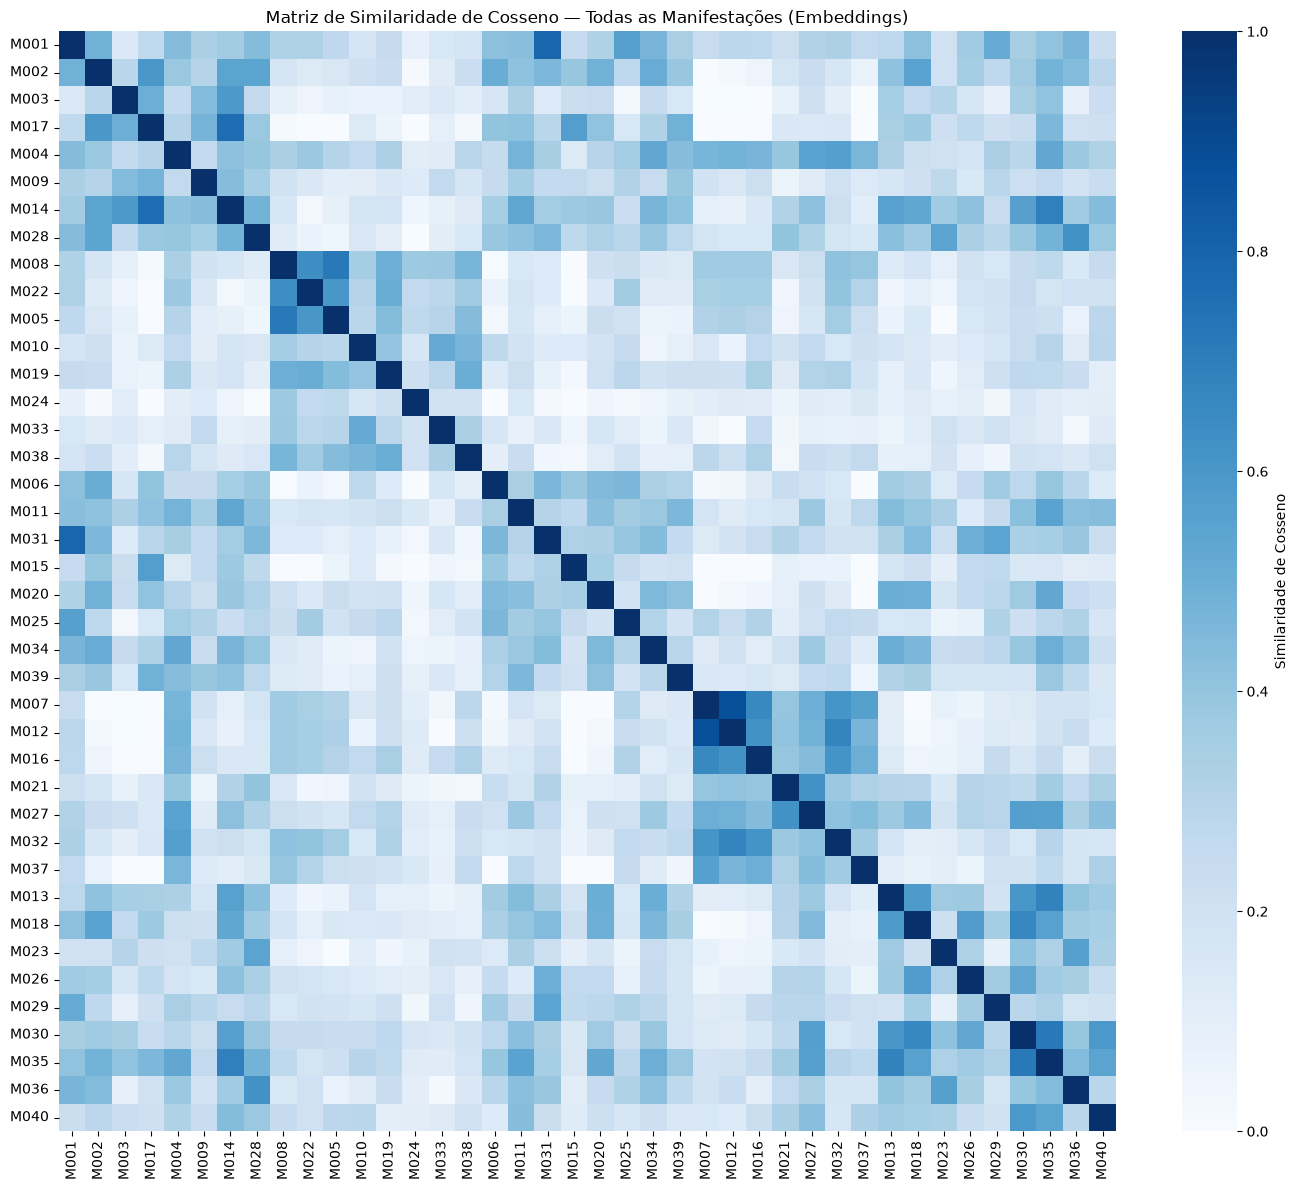

In [5]:
df_sim = pd.DataFrame(sim_completa, index=ids, columns=ids)

plt.figure(figsize=(14, 12))
sns.heatmap(df_sim, cmap="Blues", vmin=0, vmax=1, cbar_kws={"label": "Similaridade de Cosseno"})
plt.title("Matriz de Similaridade de Cosseno — Todas as Manifestações (Embeddings)")
plt.tight_layout()
plt.show()

## 5) Análise de Falsos Positivos e Falsos Negativos

Como o dataset foi construído para esta atividade, sabemos de antemão **quais pares são
duplicatas reais** (mesmo problema relatado com palavras diferentes):

- **M003 × M017** — buraco/asfalto danificado na mesma avenida
- **M008 × M022** — posto de saúde/PSF sem atendimento médico
- **M007 × M012** — falta de professor de matemática na escola municipal

Comparamos essa lista de referência com o que a função `detectar_duplicatas` encontrou.

In [6]:
duplicatas_reais = {frozenset(("M003", "M017")),
                     frozenset(("M008", "M022")),
                     frozenset(("M007", "M012"))}

detectadas = {frozenset((a, b)) for a, b, _ in pares_detectados}

verdadeiros_positivos = duplicatas_reais & detectadas
falsos_positivos = detectadas - duplicatas_reais
falsos_negativos = duplicatas_reais - detectadas

print(f"Verdadeiros positivos ({len(verdadeiros_positivos)}):")
for par in verdadeiros_positivos:
    print(" ", tuple(par))

print(f"\nFalsos positivos ({len(falsos_positivos)}) — pares detectados que NÃO são duplicatas reais:")
for par in falsos_positivos:
    print(" ", tuple(par))

print(f"\nFalsos negativos ({len(falsos_negativos)}) — duplicatas reais que a função NÃO encontrou:")
for par in falsos_negativos:
    print(" ", tuple(par))

Verdadeiros positivos (1):
  ('M012', 'M007')

Falsos positivos (0) — pares detectados que NÃO são duplicatas reais:

Falsos negativos (2) — duplicatas reais que a função NÃO encontrou:
  ('M017', 'M003')
  ('M022', 'M008')
